In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from subqcat.io import XeniumBundle
from subqcat.subsample import XeniumSampler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
bundle = XeniumBundle("/Users/priyaltripathi/SubQCAT/data/Xenium_Prime_Mouse_Brain_Coronal_FF_outs")
df = XeniumSampler(bundle)
subsampled_df = df.subsample()

In [4]:
df_grouped_by_cell = subsampled_df.groupby('cell_id')


In [5]:
df_grouped_by_cell.head()

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance
3965,281758444559544,kiiegcla-1,0,A1cf,130.171875,3876.437500,27.937500,40.00,F6,3.796875
3969,281758444569922,kiiegcla-1,1,Aatf,125.250000,3882.453125,28.421875,40.00,F6,0.000000
3971,281758444583380,kiiegcla-1,0,Abca3,127.078125,3879.109375,28.093750,40.00,F6,1.859375
3973,281758444594794,kiiegcla-1,0,Abca3,126.265625,3887.453125,22.656250,40.00,F6,1.562500
3974,281758444615853,kiiegcla-1,0,Abca7,122.234375,3885.203125,25.000000,26.50,F6,1.359375
...,...,...,...,...,...,...,...,...,...,...
2799291,281505041641941,gdffgmip-1,0,A2m,7007.218750,744.515625,13.468750,38.75,A17,0.531250
2799294,281505041507399,gdffgmip-1,1,Abca1,7013.046875,745.875000,14.203125,40.00,A17,0.000000
2799295,281505041678693,gdffgmip-1,1,Abca1,7009.812500,748.375000,13.781250,26.25,A17,0.000000
2799296,281505042049071,gdffgmip-1,1,Abca3,7009.250000,749.718750,14.453125,40.00,A17,0.000000


In [6]:
df_grouped_by_cell['cell_id'].unique()

cell_id
aabagmcb-1    [aabagmcb-1]
aabbijjj-1    [aabbijjj-1]
aabhojob-1    [aabhojob-1]
aabiojde-1    [aabiojde-1]
aabkfjcm-1    [aabkfjcm-1]
                  ...     
oiidghgi-1    [oiidghgi-1]
oijgkpjh-1    [oijgkpjh-1]
oikenajf-1    [oikenajf-1]
oilcalkg-1    [oilcalkg-1]
oilhbhom-1    [oilhbhom-1]
Name: cell_id, Length: 5000, dtype: object

In [7]:
from scipy.spatial import KDTree

nn_distances = []
for cell_id, group in df_grouped_by_cell:
    if len(group) < 2:
        nn_distances.append({'cell_id' : cell_id, 'mean_nm_distance': np.nan})
        continue
    coords = group[['x_location', 'y_location', 'z_location']].values
    tree = KDTree(coords)
    distances, _ = tree.query(coords, k=2)
    actual_nn_distances = distances[:, 1]
    mean_dist = np.mean(actual_nn_distances)
    nn_distances.append({'cell_id': cell_id, 'mean_nn_distance': mean_dist})

results_df = pd.DataFrame(nn_distances)

results_df.head()

,cell_id,mean_nn_distance
0,aabagmcb-1,0.343243
1,aabbijjj-1,0.357272
2,aabhojob-1,0.338321
3,aabiojde-1,0.355657
4,aabkfjcm-1,0.362475


In [9]:
results_df = results_df.rename(columns={'mean_nn_distance': 'distance_from_center'})

from subqcat.clustering import SpatialClusterer

clusterer = SpatialClusterer(results_df)
clustered_df = clusterer.kMeans_clustering(n_clusters=2)



In [10]:
from subqcat.quality import QCEvaluator

qc = QCEvaluator(clustered_df, bundle)
qc_results = qc.compare_clusters()



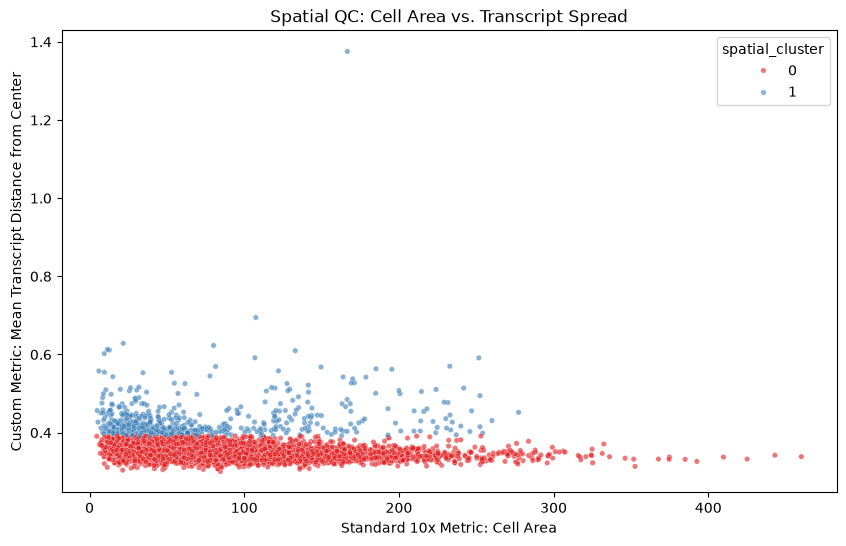

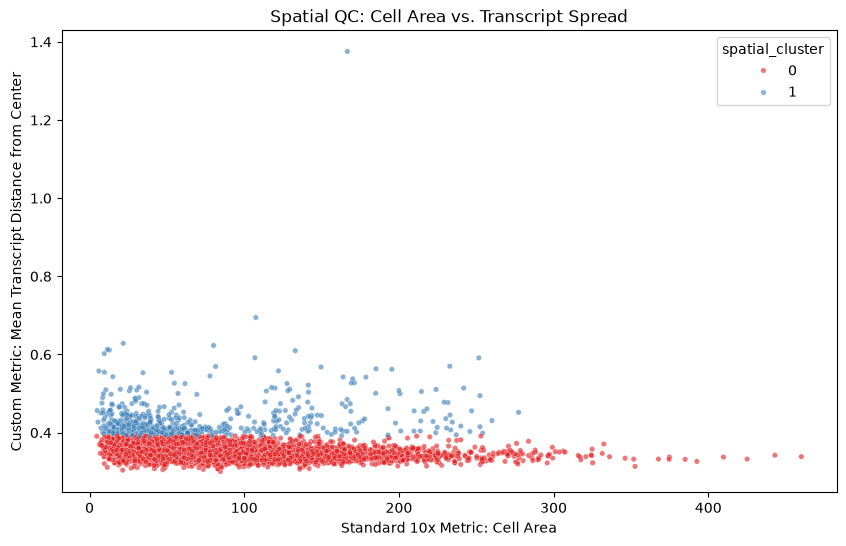

In [11]:
from subqcat.viz import SubQCATPlotter

plotter = SubQCATPlotter(qc_results['merged_df'])
plotter.scatter_plot()


In [12]:
qc_results['correlations']

{'transcript_counts': np.float64(-0.37970289787803146),
 'cell_area': np.float64(-0.14398221987848375),
 'nucleus_area': np.float64(-0.27455897052089734)}